In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
file_name = 'annular_params_test.csv'

In [5]:
df = pd.read_csv(file_name, delim_whitespace=True)

/var/folders/wb/zn41c4yx58z1ktmcwgv62zyr0000gn/T/ipykernel_40866/2762590430.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_name, delim_whitespace=True)


In [6]:
df

,Filter,D_aper,err_D_aper,D_obsc,err_D_obsc,wavel_cen,del_wavel
0,Br_alpha,36.95,0.03,10.46,0.04,4.055360,0.03400
1,Br_alpha_ref,35.80,0.03,10.10,0.04,3.936736,0.05100
2,H2O-ice,28.06,0.03,7.09,0.07,3.090090,0.23000
3,Lp,34.78,0.03,9.77,0.04,3.823116,0.56500
4,PAH_3.3,30.11,0.02,8.53,0.04,3.310648,0.07600
5,PAH_3.3_ref,31.39,0.02,8.90,0.04,3.453011,0.08200
6,short-L,29.95,0.02,8.45,0.04,3.293748,0.42200
7,IB_4.05,36.76,0.03,10.41,0.04,4.040520,0.12500
8,HCI_L,32.94,0.02,9.36,0.04,3.618517,0.22300
9,HCI_L_long,34.57,0.03,9.76,0.04,3.804904,0.27400


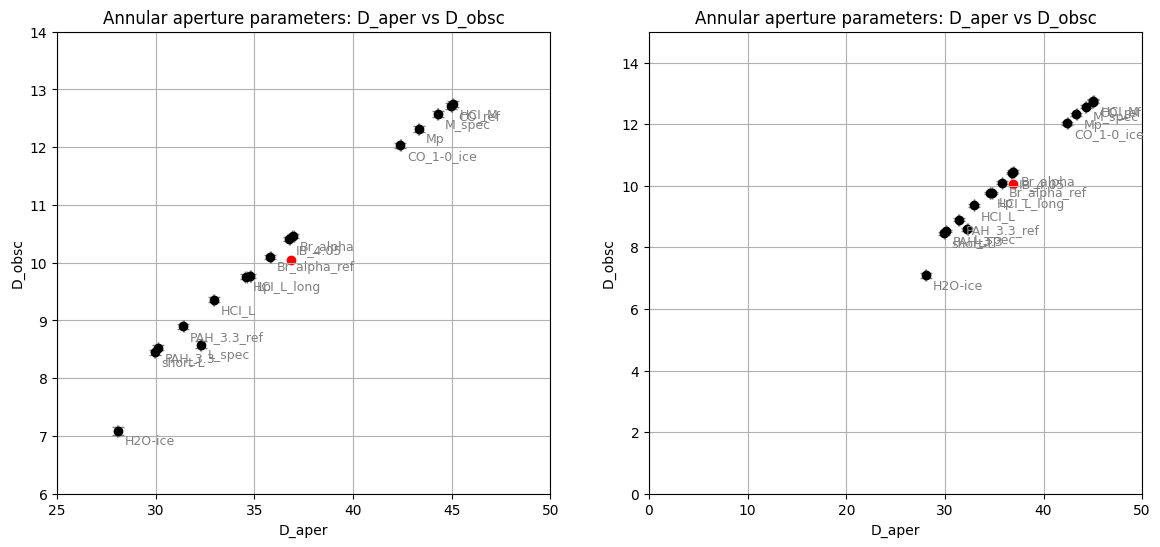

In [ ]:
def plot_annular_params(ax, df, xlim=(25, 50), ylim=(6, 14), norm=None, cmap=plt.cm.viridis):
    """Plot D_aper vs D_obsc with errorbars and annotations."""
    if norm is None:
        norm = plt.Normalize(vmin=df['wavel_cen'].min(), vmax=df['wavel_cen'].max())
    for i, row in df.iterrows():
        color = cmap(norm(row['wavel_cen']))
        ax.errorbar(
            row['D_aper'], row['D_obsc'],
            xerr=row['err_D_aper'], yerr=row['err_D_obsc'],
            fmt='o', ecolor='gray', capsize=4, markersize=6, color=color
        )
        ax.annotate(
            row['Filter'],
            (row['D_aper'], row['D_obsc']),
            textcoords="offset points",
            xytext=(5, -10),
            ha='left',
            fontsize=9,
            color='gray'
        )
    ax.scatter([36.876], [10.053], c='red')
    ax.set_xlabel('D_aper')
    ax.set_ylabel('D_obsc')
    ax.set_title('Returned annular aperture parameters (D_aper, D_obsc)')
    ax.grid(True)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
norm = plt.Normalize(vmin=df['wavel_cen'].min(), vmax=df['wavel_cen'].max())
plot_annular_params(ax1, df, norm=norm)
plot_annular_params(ax2, df, xlim=(0, 50), ylim=(0, 15), norm=norm)  # different limits for zoomed view
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=plt.cm.viridis), ax=[ax1, ax2], label='wavel_cen (µm)')
#plt.legend()
#plt.show()
plt.savefig('junk_annular_params_test.png')